<a href="https://colab.research.google.com/github/Schr0dinger0/university_Image_Processing/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961_%D0%9E%D1%81%D0%BD%D0%BE%D0%B2%D0%BD%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_OpenCV_%D0%A7%D0%B0%D1%81%D1%82%D1%8C_%E2%84%961.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №1. Основные методы OpenCV. Часть №1**

In [5]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

---

# **Тема №1. Чтение, запись и отображение**



## **Задание 1:**  
Напишите процедуру, которая:

- Считывает цветное изображение в режиме `cv2.IMREAD_COLOR`.
- Преобразует его в оттенки серого с использованием `cv2.cvtColor()`.
- Сохраняет полученное черно-белое изображение на диск.
- Отображает оба изображения (оригинальное цветное и преобразованное черно-белое).




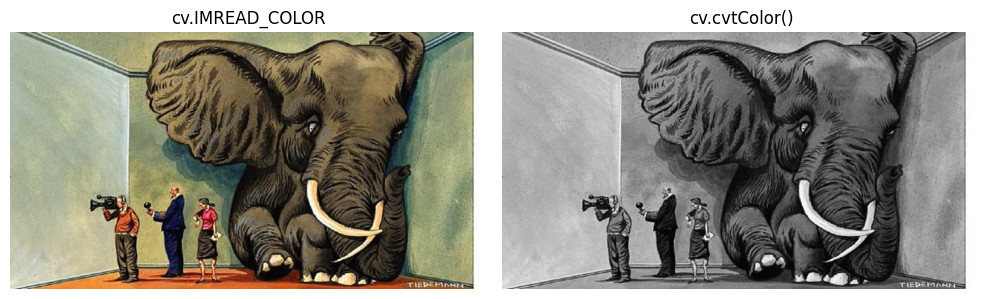

In [11]:
# Путь к изображению
image_path = '/content/слоник(не зелёный).jpg'

# Загрузка изображений
img_color = cv.imread(image_path, cv.IMREAD_COLOR)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

cv.imwrite("слоник(серый).jpg", img_gray)

# Создание фигуры для отображения
plt.figure(figsize=(10, 5))

# Отображение цветного изображения
img_color_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
plt.subplot(1, 2, 1)
plt.imshow(img_color_rgb)
plt.title('cv.IMREAD_COLOR')
plt.axis('off')

# Отображение изображения в оттенках серого
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('cv.cvtColor()')
plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание 2:**  
Используя режим `cv2.IMREAD_UNCHANGED`, загрузите изображение с альфа-каналом (например, PNG с прозрачностью). Затем:

- Разделите изображение на каналы (B, G, R, A).
- Создайте новое изображение, где прозрачность (альфа-канал) инвертирована (т.е. прозрачные области становятся непрозрачными и наоборот).
- Сохраните и отобразите полученное изображение.

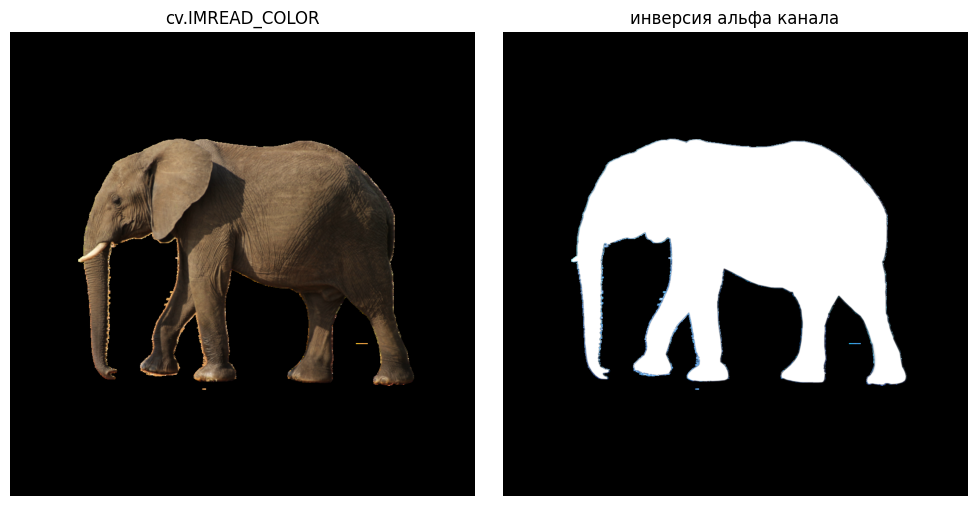

In [17]:
# Путь к изображению
image_path = '/content/слоник(прозрачный).png'

# Загрузка изображений
img_color = cv.imread(image_path, cv.IMREAD_UNCHANGED)

b_channel, g_channel, r_channel, a_channel = cv.split(img_color)
a_inverted = 255 - a_channel

img_inverted = cv.merge((b_channel, g_channel, r_channel, a_inverted))

cv.imwrite("слоник(антипрозрачный).png", img_inverted)

# Создание фигуры для отображения
plt.figure(figsize=(10, 5))

# Отображение цветного изображения
img_color_rgb = cv.cvtColor(img_color, cv.COLOR_BGRA2RGB)
plt.subplot(1, 2, 1)
plt.imshow(img_color_rgb)
plt.title('cv.IMREAD_COLOR')
plt.axis('off')

# Отображение изображения в оттенках серого
plt.subplot(1, 2, 2)
plt.imshow(img_inverted)
plt.title('инверсия альфа канала')
plt.axis('off')

plt.tight_layout()
plt.show()

---

# **Тема №2. Работа с цветовыми палитрами**



## **Задание 3:**  
Напишите процедуру, которая:

- Считывает цветное изображение.
- Преобразует его из цветового пространства BGR в HSV с помощью `cv2.cvtColor()`.
- Увеличивает насыщенность (канал S) в 1.5 раза, не превышая максимального значения.
- Преобразует изображение обратно в цветовое пространство BGR.
- Отображает оригинальное и полученное изображения рядом для сравнения.

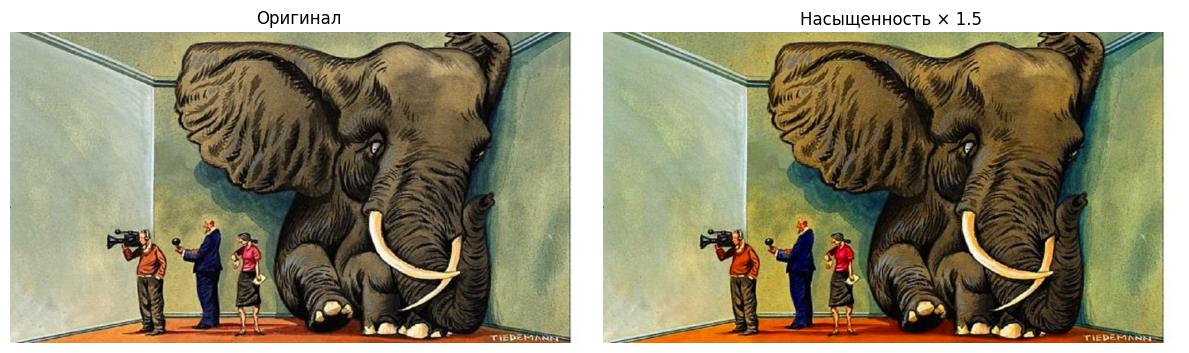

In [18]:
# 1. Считываем цветное изображение
img_color = cv.imread("/content/слоник(не зелёный).jpg", cv.IMREAD_COLOR)

# 2. Преобразуем BGR -> HSV
img_hsv = cv.cvtColor(img_color, cv.COLOR_BGR2HSV).astype(np.float32)

# 3. Увеличиваем насыщенность (канал S) в 1.5 раза
img_hsv[:, :, 1] = np.clip(img_hsv[:, :, 1] * 1.5, 0, 255)

# Приводим обратно к типу uint8
img_hsv = img_hsv.astype(np.uint8)

# 4. Преобразуем обратно HSV -> BGR
img_result = cv.cvtColor(img_hsv, cv.COLOR_HSV2BGR)

# 5. Отображаем оригинал и результат рядом
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB))
plt.title('Насыщенность × 1.5')
plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание 4:**  
Напишите процедуру, которая:

- Считывает изображение и Преобразует его в цветовое пространство YCrCb.
- Применяет размытие к компоненте яркости Y (при помощи фильтра, см. материал предыдущих занятий).
- Снова Преобразует изображение в цветовое пространство BGR.
- Отображает исходное и размытое изображения.

In [ ]:
# Ваш код

---

# **Тема №3. Слияние и усиление**

## **Задание 5:**  
Создайте процедуру, которая:

- Считывает два изображения одинакового размера (можно подкорректировать с помощью метода `.resize()`).
- Выполняет побитовое ИЛИ (OR) над соответствующими пикселями двух изображений.
- Сохраняет и отображает результат операции.

In [ ]:
# Ваш код

## **Задание 6:**  
Реализуйте следующий алгоритм:

- Считайте цветное изображение и разделите его на три канала с использованием `.split()`.
- Примените к каждому каналу разный коэффициент гамма-коррекции (например, для R – 0.5, G – 1.0, B – 1.5).
- Объедините каналы обратно с помощью `.merge()`.
- Отобразите исходное и обработанное изображения.


In [ ]:
# Ваш код

---

# **Тема №4. Работа с гистограммами в OpenCV**

## **Задание 7:**  
Напишите процедуру для улучшения контрастности изображения:

- Считывает изображение в оттенках серого.
- Строит его гистограмму с использованием `cv.calcHist()`.
- Применяет эквализацию гистограммы методом `cv2.equalizeHist()`.
- Отображает на одном графике исходное и эквализованное изображения вместе с их гистограммами.

In [ ]:
# Ваш код

## **Задание 8:**  
Используйте метод CLAHE для улучшения деталей в затемненных областях цветного изображения:

- Преобразуйте изображение из BGR в LAB цветовое пространство.
- Разделите изображение на каналы и примените `cv2.createCLAHE()` к каналу яркости L.
- Объедините обработанный канал L с исходными каналами A и B.
- Преобразуйте изображение обратно в BGR.
- Отобразите исходное и обработанное изображения для сравнения вместе с их гистограммами.

In [ ]:
# Ваш код

## **Затем:**  
Исследуйте влияние размера окна (tileGridSize) и порога по сравнению с гистограммой (clipLimit) в методе CLAHE на конечный результат. Попробуйте несколько различных значений и визуализируйте результаты.


In [ ]:
# Ваш код

---

# **Комплексное задание №1. Улучшение качества отсканированного документа с использованием OpenCV**



## **Краткое описание задания:**

- Необходимо написать функцию для улучшения качества отсканированного документа с использованием методов обработки изображений, изученных ранее. Функция должна принимать на вход изображение отсканированного документа и возвращать его улучшенную версию, готовую для дальнейшего использования, например, для распознавания текста.

Датасет с отсканированными изображениями можно найти в сети Интернет.

---



## **Алгоритм действий:**

#### **Реализуйте функцию на языке Python с использованием библиотеки OpenCV, которая выполняет следующие этапы обработки:**

### **1. Чтение, запись и отображение изображений:**

- Функция должна принимать на вход изображение отсканированного документа (например, в формате JPEG или PNG)
- Проверьте наличие альфа-канала в изображении и, если он присутствует, загрузите изображение в режиме `cv2.IMREAD_UNCHANGED`, иначе используйте `cv2.IMREAD_COLOR`
- Отобразите исходное изображение для визуальной проверки

### **2. Работа с цветовыми палитрами:**

- Преобразуйте изображение в оттенки серого, используя `cv2.cvtColor()` с параметром `cv2.COLOR_BGR2GRAY`.
- Отобразите полученное изображение в оттенках серого.

### **3. Слияние и усиление:**

- Примените медианный фильтр (`cv2.medianBlur()`) для удаления шумов с изображения. Выберите подходящий размер ядра (например, 3 или 5). Отобразите результат.
- Используйте фильтр сглаживания с применением прямой свертки (`cv2.filter2D()`) с заданным ядром для повышения четкости. Например, можно использовать фильтр "Unsharp Masking":
  - Создайте ядро для повышения резкости. Пример ядра:
    ```python
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    ```
  - Примените фильтр к изображению и отобразите результат.

### **4. Работа с гистограммами:**

- Примените метод CLAHE (Contrast Limited Adaptive Histogram Equalization) для улучшения контрастности изображения:
  - Создайте объект CLAHE с параметрами `clipLimit=2.0` и `tileGridSize=(8,8)`.
  - Примените CLAHE к изображению.
  - отобразите результат.
- Постройте гистограммы яркости исходного и обработанного изображений для сравнения.

---

### **Требования к функции:**

- Функция должна называться: `improve_scan(image)`, где `image` — входное изображение в виде массива NumPy.
- Функция должна возвращать улучшенное изображение в виде массива NumPy.
- В ходе работы функция должна **опционально** отображать промежуточные результаты для наглядности (в условиях Colab использовать соответствующие методы вывода изображений). Для этого следует ввести отдельный параметр (например: `visible=True`) и реализовать с ним соответствующую логику.

---

### **Дополнительные требования:**

- **Обработка ошибок:**
  - Убедитесь, что функция корректно обрабатывает ситуации, когда на вход подается некорректное изображение.
  - Добавьте проверки на тип входных данных.

- **Документация и комментарии:**
  - Функция должна быть снабжена понятной документацией: опишите, какие преобраования выполняются и для чего.
  - Добавьте комментарии к основным участкам кода для пояснения выполняемых действий.



---

### **Подсказки и рекомендации:**


- **Медианный фильтр:**
  Функция `cv2.medianBlur(src, ksize)` принимает на вход изображение и размер ядра (должен быть нечетным числом).

- **CLAHE:**
  - Создайте объект CLAHE с помощью `cv2.createCLAHE(clipLimit, tileGridSize)`.
  - Примените метод `apply()` к изображению в оттенках серого.

- **Отображение изображений в Google Colab:**
  - Используйте `matplotlib.pyplot` для отображения изображений.
  - Помните, что `cv2.imread()` загружает изображения в формате BGR, поэтому для корректного отображения в Matplotlib Преобразуйте изображение в RGB с помощью `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`.

---

In [ ]:
# Ваш код

## **Дополнительное задание:**

- Поэкспериментируйте с параметрами медианного фильтра, ядром для фильтра повышения резкости и параметрами CLAHE для достижения наилучшего результата.
- Добавьте возможность передачи этих параметров в функцию `improve_scan` для более гибкой настройки обработки. **В качестве параметров по умолчанию установите те, которые показали себя лучше всего по результатам экспериментов**

**Пример с параметрами:**

```python
def improve_scan(image,
                 median_kernel_size=3,
                 sharp_kernel= np.array([[-1, -1, -1],
                                         [-1,  9, -1],
                                         [-1, -1, -1]]),
                 clahe_clip=2.0,
                 clahe_grid=(8,8),
                 visible=True):
    # Реализация с учетом переданных параметров
    ...
```


In [ ]:
# Ваш код